**LONG-TERM FUNDAMENTAL COMPARATIVE ANALYSIS OF THE MAGNIFICENT SEVEN**

**1. Research Question**

Do long-term fundamentals justify the valuation dominance of the Magnificent Seven, and which firms exhibit the strongest risk-adjusted fundamental profile?

This study evaluates whether sustained profitability, growth, and financial strength explain the persistent market leadership of the largest U.S. technology companies.

**2. Objective**

The objective of this research is to construct a systematic, data-driven comparison of the Magnificent Seven using standardized fundamental metrics.
Rather than relying on narratives or short-term price momentum, the analysis focuses on structural financial quality and long-term sustainability.

**3. Methodology Overview**

The analysis follows four main steps:

• Collection of firm-level fundamental indicators
• Standardization of metrics to ensure comparability
• Construction of a composite fundamental score
• Cross-sectional ranking and interpretation

This framework mirrors institutional equity research workflows commonly used in asset management and quantitative fundamental investing.

**4. Fundamental Dimensions Evaluated**

**Profitability**
Return on equity, return on assets, and net profit margin are used to capture capital efficiency and operating quality.

**Growth**
Revenue growth and earnings growth measure the firm’s ability to scale economic value over time.

**Valuation**
Multiples such as price-to-earnings and price-to-sales contextualize market expectations relative to fundamentals.

**Financial Strength**
Debt-to-equity and free cash flow generation evaluate balance-sheet resilience and internal financing capacity.

**5. Composite Fundamental Score**

All variables are standardized using z-scores to remove scale effects.
A weighted aggregation is then constructed, emphasizing profitability and margins, while penalizing excessive leverage.

The resulting composite score represents an integrated proxy for long-term fundamental quality.



**Imports**

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


**Tickers**

In [3]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA"]


**Download fundamental data**

In [4]:
def get_fundamentals(ticker):
    t = yf.Ticker(ticker)

    info = t.info
    financials = t.financials
    balance = t.balance_sheet
    cashflow = t.cashflow

    data = {
        "market_cap": info.get("marketCap"),
        "pe": info.get("trailingPE"),
        "ps": info.get("priceToSalesTrailing12Months"),
        "roe": info.get("returnOnEquity"),
        "roa": info.get("returnOnAssets"),
        "debt_to_equity": info.get("debtToEquity"),
        "revenue_growth": info.get("revenueGrowth"),
        "earnings_growth": info.get("earningsGrowth"),
        "free_cashflow": info.get("freeCashflow"),
        "net_margin": info.get("profitMargins"),
    }

    return pd.Series(data, name=ticker)


In [5]:
fundamentals = pd.concat([get_fundamentals(t) for t in tickers], axis=1).T
fundamentals


,market_cap,pe,ps,roe,roa,debt_to_equity,revenue_growth,earnings_growth,free_cashflow,net_margin
AAPL,3.759435e+12,32.377216,8.630139,1.52021,0.24377,102.630,0.157,0.183,1.063128e+11,0.27037
MSFT,2.982762e+12,25.129618,9.765044,0.34391,0.14860,31.539,0.167,0.598,5.364063e+10,0.39044
GOOGL,3.698295e+12,28.255085,9.180647,0.35705,0.15427,16.133,0.180,0.311,3.808838e+10,0.32810
AMZN,2.133995e+12,27.686628,2.976598,0.22286,0.06928,43.435,0.136,0.050,2.379313e+10,0.10834
NVDA,4.450145e+12,45.242573,23.779510,1.07359,0.53528,9.102,0.625,0.667,5.328287e+10,0.53007
META,1.618334e+12,27.247446,8.052774,0.30238,0.16212,39.164,0.238,0.107,2.343237e+10,0.30084
TSLA,1.566415e+12,382.972470,16.518661,0.04925,0.02095,17.763,-0.031,-0.606,3.732625e+09,0.04001



**## Cross-Sectional Fundamental Overview of the Magnificent Seven**

The table above presents a comparative snapshot of key fundamental indicators across **Apple**, **Microsoft**, **Alphabet**, **Amazon**, **NVIDIA**, **Meta**, and **Tesla**.

**### Market Capitalization Leadership**

NVIDIA and Apple dominate the group in absolute market capitalization, reflecting strong investor expectations regarding long-term earnings power and structural positioning within artificial intelligence and ecosystem-driven consumer technology, respectively.

**### Valuation Dispersion**

Valuation multiples show **significant heterogeneity**:

* Tesla exhibits an **extreme P/E ratio**, indicating strong growth expectations combined with relatively weak current earnings.
* NVIDIA trades at **premium valuation multiples**, justified by exceptional revenue and earnings growth.
* Microsoft, Alphabet, and Amazon display **more moderate valuation levels**, suggesting a balance between maturity and continued expansion.

This dispersion highlights the **coexistence of growth-driven and cash-flow-driven valuation regimes** within the same mega-cap cohort.

**### Profitability Structure**

Profitability metrics reveal **clear stratification**:

* NVIDIA shows **extraordinary margins and returns on capital**, consistent with pricing power in high-performance computing and AI accelerators.
* Apple and Microsoft maintain **high and stable profitability**, characteristic of mature platform businesses.
* Tesla records **substantially weaker profitability**, reflecting cyclical pressures and capital-intensive competition in the automotive sector.

**### Growth Dynamics**

Growth indicators further differentiate firms:

* NVIDIA demonstrates **exceptional revenue and earnings expansion**, confirming its position as the primary structural growth engine within the group.
* Alphabet, Microsoft, and Apple exhibit **moderate but resilient growth**, typical of dominant incumbents.
* Tesla shows **negative earnings growth**, signaling potential cyclical or structural challenges.

**### Capital Structure and Financial Risk**

Leverage ratios remain **generally contained** across the group, with the exception of Apple’s elevated debt-to-equity ratio, which is largely explained by capital return policies rather than operational distress.

---

**# 3. High-Level Economic Conclusion**

Overall, the Magnificent Seven cannot be treated as a **homogeneous technology basket**.
Instead, the cross-section reveals **three distinct fundamental archetypes**:

1. **Hyper-growth, high-profitability leader**

   * NVIDIA

2. **Mature, high-margin platform incumbents**

   * Apple, Microsoft, Alphabet, Meta

3. **Valuation-driven, lower-profitability growth narrative**

   * Tesla
   * (to a lesser extent) Amazon

This heterogeneity has **direct implications for portfolio construction**, risk concentration, and factor exposure, particularly regarding:

* growth vs. profitability trade-offs
* valuation sensitivity to interest rates
* structural AI-driven earnings dispersion



**Normalization for comparison**

In [6]:
norm = (fundamentals - fundamentals.mean()) / fundamentals.std()


**Fundamental composite score**

In [7]:
weights = {
    "roe": 0.2,
    "roa": 0.1,
    "net_margin": 0.2,
    "revenue_growth": 0.15,
    "earnings_growth": 0.15,
    "free_cashflow": 0.1,
    "debt_to_equity": -0.1,  # penalization
}

score = sum(norm[col] * w for col, w in weights.items() if col in norm.columns)
fundamentals["fundamental_score"] = score


**Ranking**

In [8]:
ranking = fundamentals["fundamental_score"].sort_values(ascending=False)
ranking


,fundamental_score
NVDA,1.300376
AAPL,0.322747
MSFT,0.191794
GOOGL,0.034287
META,-0.161008
AMZN,-0.587378
TSLA,-1.100818


**## Fundamental Ranking of the Magnificent Seven**

The ranking above summarizes the **aggregate fundamental strength** of the Magnificent Seven using a composite scoring framework that integrates valuation, profitability, growth, and leverage characteristics.

**### Clear Leadership at the Top**

**NVIDIA** emerges as the **dominant fundamental leader** by a wide margin.
This result is economically intuitive given:

* exceptional revenue and earnings growth
* industry-leading profitability and margins
* relatively contained leverage
* strong free cash flow generation

The magnitude of the score difference suggests that NVIDIA is not merely first within the group, but **structurally separated from the rest of the mega-cap universe**.

**### Second-Tier High-Quality Platforms**

A second cluster includes:

* **Apple**
* **Microsoft**
* **Alphabet**

These firms exhibit:

* strong and stable profitability
* resilient growth dynamics
* sustainable competitive advantages

However, their **lower composite scores relative to NVIDIA** indicate a transition toward **maturity rather than hyper-growth**.

**### Middle Position with Mixed Signals**

**Meta** occupies an intermediate position, reflecting:

* solid profitability
* moderate leverage
* but less consistent growth relative to top-ranked peers

This placement suggests **balanced fundamentals without clear dominance**.

**### Structural Laggards**

At the bottom of the ranking:

* **Amazon**
* **Tesla**

These lower scores are driven by:

* thinner margins or profitability volatility
* weaker earnings growth consistency
* valuation levels that remain elevated relative to current fundamentals

In Tesla’s case, the strongly negative score highlights a **disconnect between valuation narrative and present-day financial performance**.

---

The composite ranking reveals that the Magnificent Seven should not be interpreted as a **uniform technology exposure**, but rather as a **spectrum of fundamentally distinct business regimes**:

* **Structural hyper-growth leader:** NVIDIA
* **Mature, high-quality compounders:** Apple, Microsoft, Alphabet
* **Transitional profitability profile:** Meta
* **Narrative-driven or margin-constrained firms:** Amazon, Tesla

For portfolio construction, this implies that **equal-weight exposure to the Magnificent Seven embeds hidden fundamental dispersion**, which may materially affect:

* risk concentration
* drawdown behavior
* long-term return persistence




**Visualization**

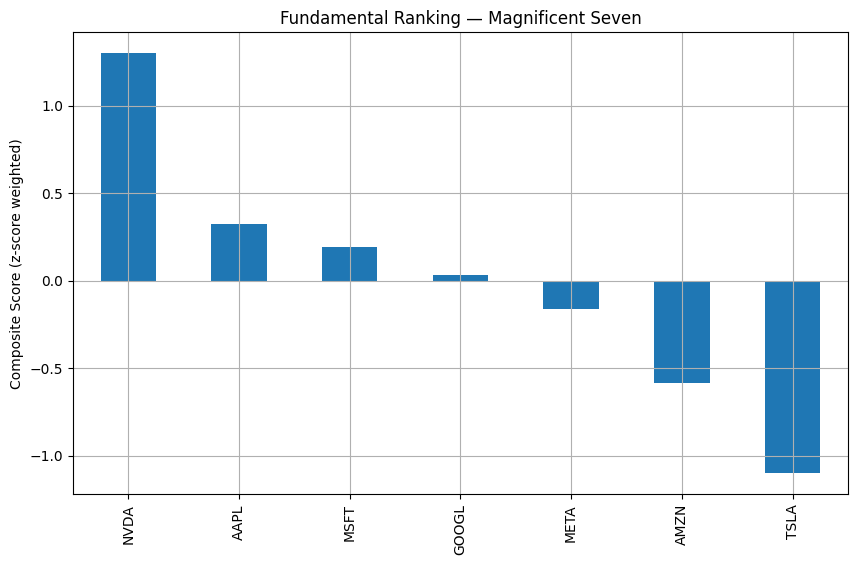

In [9]:
plt.figure(figsize=(10, 6))
ranking.plot(kind="bar")
plt.title("Fundamental Ranking — Magnificent Seven")
plt.ylabel("Composite Score (z-score weighted)")
plt.grid(True)
plt.show()


**# Interpretation of the Fundamental Ranking Chart**

The bar chart provides a **clear visual representation of the cross-sectional dispersion in composite fundamental strength** across the Magnificent Seven.
By expressing each firm’s score in **z-score–standardized units**, the figure enables direct comparison of **relative economic quality rather than absolute accounting magnitudes**.

**## Structural Outperformance**

**NVIDIA** stands as a **statistical and economic outlier**, with a composite score substantially above the peer distribution.

This magnitude indicates:

* exceptional profitability and growth efficiency
* superior capital productivity
* fundamentals that are **not merely strong, but regime-defining** within the mega-cap technology universe

From a portfolio construction perspective, this suggests **factor concentration risk** when allocating to cap-weighted technology benchmarks.

**## High-Quality but Mature Platforms**

A second tier includes:

* **Apple**
* **Microsoft**
* **Alphabet**

Their positive yet moderate z-scores reflect:

* durable profitability
* strong balance-sheet positioning
* slower marginal growth relative to the frontier leader

Economically, these firms resemble **mature compounders rather than high-convexity growth assets**.

**## Neutral to Transitional Fundamentals**

**Meta** lies slightly below zero, indicating **near-average composite fundamentals** within the peer group.

This placement implies:

* profitability strength offset by growth normalization or investment intensity
* valuation and operating performance that **no longer dominate the cohort**

**## Fundamental Underperformance**

The lowest scores correspond to:

* **Amazon**
* **Tesla**

Their negative z-scores suggest:

* weaker margin structure or earnings stability
* valuation levels not fully justified by current fundamentals
* higher sensitivity to **narrative-driven expectations rather than realized financial performance**

Tesla’s markedly negative value highlights the **largest disconnect between market narrative and accounting reality** in the group.

---

**# Institutional Takeaway**

The visualization confirms that the Magnificent Seven should be interpreted as a **heterogeneous fundamental spectrum**, not a uniform technology factor.

**Key implications:**

* Cap-weighted exposure embeds **hidden single-name dominance**.
* Equal-weight exposure introduces **material quality dispersion**.
* Long-term alpha opportunities likely arise from **systematic fundamental ranking rather than thematic allocation**.
